# PS5 — Question 1: Vectorized Quote Path

This notebook implements the Avellaneda--Stoikov quote computation vectorized over an inventory grid in PyTorch, then benchmarks the latency distribution.

For each inventory value $q$, the quotes are

$$r(q)=S-q\gamma\sigma^2\tau,$$

$$\delta^*=\frac{1}{\gamma}\log\left(1+\frac{\gamma}{\kappa}\right)+\frac{1}{2}\gamma\sigma^2\tau,$$

$$bid(q)=r(q)-\delta^*, \qquad ask(q)=r(q)+\delta^*.$$

The whole inventory grid is computed as one tensor operation instead of a Python loop.

In [1]:
import sys
from pathlib import Path

tools_path = Path('../../.tools/python').resolve()
if tools_path.exists():
    sys.path.insert(0, str(tools_path))

from vectorized_quote_path import QuoteBenchmarkParams, run_ps5_q1

params = QuoteBenchmarkParams(q_min=-100, q_max=100, benchmark_runs=5000, warmup_runs=200)
quote_grid, latency, summary = run_ps5_q1(params)
summary

,device,dtype,num_threads,inventory_points,runs,mean_us,median_us,p95_us,p99_us,min_us,max_us
0,cpu,float64,1,201,5000,111.72198,99.8,177.105,297.215,94.1,1511.2


In [2]:
quote_grid.head(), quote_grid.tail()

(   inventory         bid         ask   spread  mid_price
 0     -100.0  139.154615  140.845385  1.69077      100.0
 1      -99.0  138.754615  140.445385  1.69077      100.0
 2      -98.0  138.354615  140.045385  1.69077      100.0
 3      -97.0  137.954615  139.645385  1.69077      100.0
 4      -96.0  137.554615  139.245385  1.69077      100.0,
      inventory        bid        ask   spread  mid_price
 196       96.0  60.754615  62.445385  1.69077      100.0
 197       97.0  60.354615  62.045385  1.69077      100.0
 198       98.0  59.954615  61.645385  1.69077      100.0
 199       99.0  59.554615  61.245385  1.69077      100.0
 200      100.0  59.154615  60.845385  1.69077      100.0)

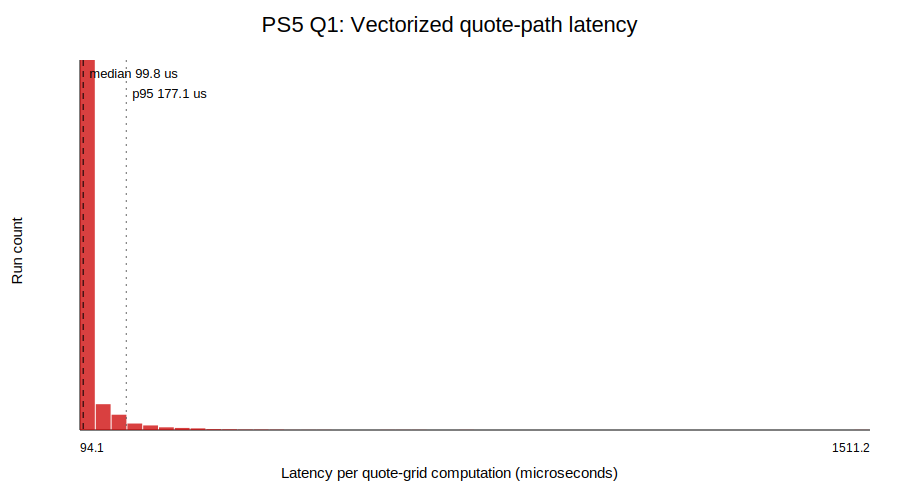

In [3]:
from IPython.display import Image, display

display(Image(filename='figures/quote_grid_latency_distribution.png'))

## Conclusion

The vectorized quote path computes all inventory-grid quotes in one PyTorch call. The benchmark reports mean, median, p95, and p99 latency across repeated local runs.